# Cold start on the IDAES CSTR

The saponification CSTR carries a full algebraic layer: the outlet
stream, the reaction-rate cascade, and the indexed holdup's water member.
`drto.cold_start_dynamic` seeds the states on straight lines to their
declared targets and solves that algebra pointwise, so the guess is
consistent everywhere except the declared dynamics.

The plots show the model before the initialization and after it; the
report shows the per-point solves working through the algebra.

In [1]:
%matplotlib inline
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import drto
from drto import plot_controls, plot_stage_cost, plot_states
from idaes.core.util.model_statistics import degrees_of_freedom
from models.idaes_cstr import (
    DC_START, F_IN, VOLUME, build, scaled_solve, tag_scaling)


In [2]:
m = build()
drto.info(m)

horizon,"fs._time (ContinuousSet, 31 points)"
states,"fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]) for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)"
tracking stage cost,"cost[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((fs.cstr._flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','NaOH'] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','EthylAcetate'] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','SodiumAcetate'] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','Ethanol'] - ss_etoh)/scale_M)**2 for t in sorted(fs._time)[:-1]"
terminal cost,"term == ((fs.cstr.control_volume.material_holdup[10.0,Liq,NaOH] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,EthylAcetate] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,SodiumAcetate] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,Ethanol] - ss_etoh)/scale_M)**2 + ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2"
initial conditions,"mat0[j] == fs.cstr.control_volume.material_holdup[0.0,'Liq',j] for j in OrderedScalarSet (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## The setpoint and the start

The steady solve fills the targets, and the initial condition is the
setpoint composition knocked back along the reaction, hot.

In [3]:
def plot_rates(m):
    """The undeclared algebraic pair: the rate constant and the rate."""
    rxn = m.fs.cstr.control_volume.reactions
    grid = sorted(m.fs.time)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
    for ax, name, vals in (
        (axes[0], "k_rxn [m3/mol/s]",
         [pyo.value(rxn[t].k_rxn) for t in grid]),
        (axes[1], "reaction_rate[R1] [mol/m3/s]",
         [pyo.value(rxn[t].reaction_rate["R1"]) for t in grid]),
    ):
        ax.plot(grid, vals, ".-")
        ax.set_title(name)
        ax.set_xlabel("time [s]")

In [4]:
ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                 m.fs.cstr.inlet.flow_vol.name: F_IN})
assert degrees_of_freedom(ss) == 0
scaled_solve(ss, tee=True)

cvs = ss.fs.cstr.control_volume
print(f"setpoint  T = {pyo.value(cvs.properties_out[0.0].temperature):7.3f} K"
      f"   NaOH = {pyo.value(cvs.properties_out[0.0].conc_mol_comp['NaOH']):6.3f} mol/m3")

for j, ssp in (("NaOH", m.ss_naoh), ("EthylAcetate", m.ss_ea),
               ("SodiumAcetate", m.ss_sa), ("Ethanol", m.ss_etoh)):
    ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
# the start: the setpoint composition with conversion knocked back by
# DC_START along the reaction stoichiometry, hot by T_START - T_ss
for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
               ("SodiumAcetate", -1), ("Ethanol", -1)):
    m.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
for k in m.eng_ss:
    m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
drto.info(ss)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpi1riqzug.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpi1riqzug.pyomo.nl...
Parsed 22 vars, 2

setpoint  T = 304.039 K   NaOH = 24.286 mol/m3


states,"fs.cstr.control_volume.material_holdup_Liq_NaOH (free), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free), fs.cstr.control_volume.energy_holdup (free)"
dynamics,"fs.cstr.control_volume.material_accumulation[o,_r] == fs.cstr.control_volume.properties_in[0.0].flow_vol*fs.cstr.control_volume.properties_in[0.0].conc_mol_comp[_r] - fs.cstr.control_volume.properties_out[0.0].flow_vol*fs.cstr.control_volume.properties_out[0.0].conc_mol_comp[_r] + fs.cstr.control_volume.rate_reaction_generation[o,_r] for o in fs.props._phase_component_set (inc)"
dynamics,fs.cstr.control_volume.energy_accumulation[Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[0.0].flow_vol*(fs.cstr.control_volume.properties_in[0.0].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[0.0].flow_vol*(fs.cstr.control_volume.properties_out[0.0].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[R1] (inc)
controls,"fs.cstr.control_volume.heat (fixed), fs.cstr._flow_vol_inlet_ref (fixed, m**3/s)"
steady-state targets,"ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## The controller model

The terminal segment joins at definition time: the infinite-horizon
transformation applies before any plot or initialization, so the cold
start also covers the tail. The steady reduction above branches from
the plain declarations, which is why it runs first.

In [5]:
pyo.TransformationFactory("drto.infinite_horizon").apply_to(m)
drto.info(m)

horizon,"fs._time (ContinuousSet, 31 points)"
states,"fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]) for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)"
tracking stage cost,"cost[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((fs.cstr._flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','NaOH'] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','EthylAcetate'] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','SodiumAcetate'] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','Ethanol'] - ss_etoh)/scale_M)**2 for t in sorted(fs._time)[:-1]"
terminal cost,"term == ((fs.cstr.control_volume.material_holdup[10.0,Liq,NaOH] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,EthylAcetate] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,SodiumAcetate] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,Ethanol] - ss_etoh)/scale_M)**2 + ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2"
initial conditions,"mat0[j] == fs.cstr.control_volume.material_holdup[0.0,'Liq',j] for j in OrderedScalarSet (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## Before

The builder's values: flat, and unaware of the initial condition. The
rate constant and the reaction rate sit at the property package's
defaults.

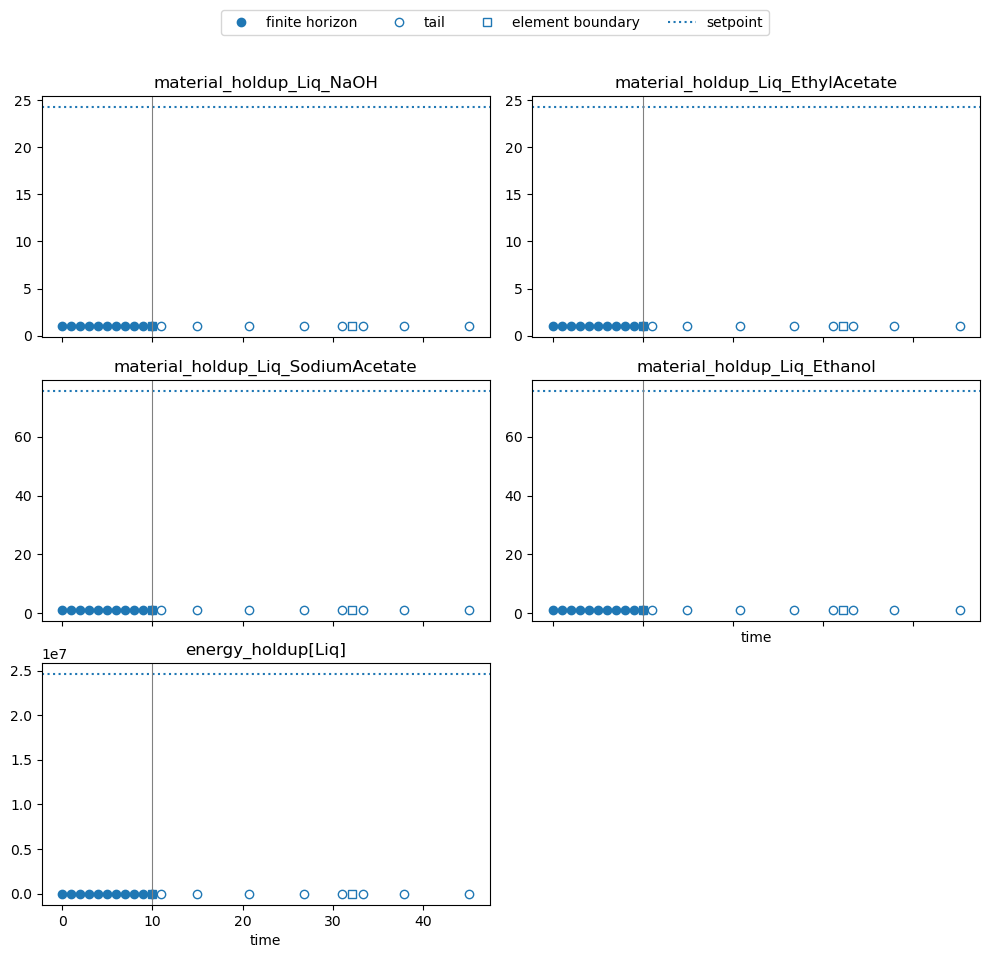

In [6]:
plot_states(m);
plt.show()

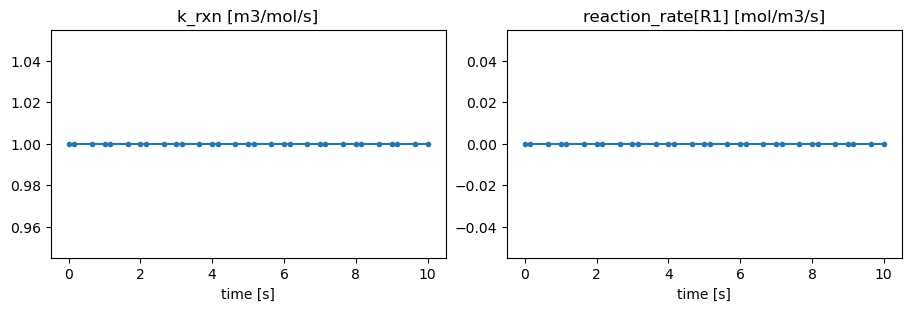

In [7]:
plot_rates(m)
plt.show()

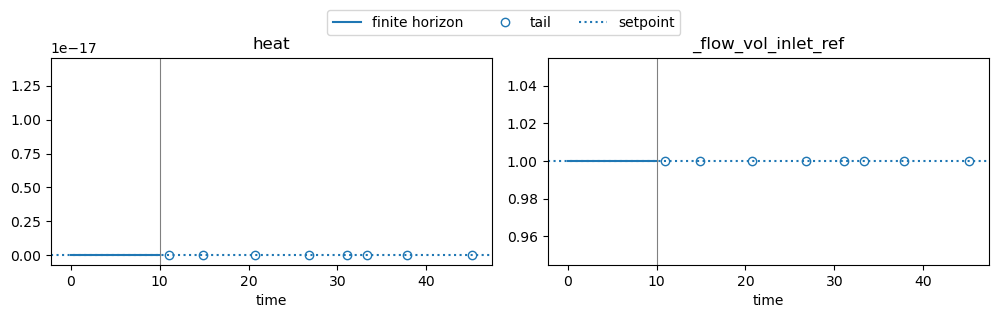

In [8]:
plot_controls(m)
plt.show()

## The cold start

States on their lines, controls at their targets, the tail at rest on
the targets with the pin slacks at zero, and one block solve working
the outlet stream, the reaction cascade, and the water member
consistent at every grid point, the segment's included. The model
carries its units-driven scaling factors before the call, so the
per-point solves run on a scaled clone and the values come back in the
model's own units.

In [9]:
tag_scaling(m)
print(drto.cold_start_dynamic(m))

drto cold_start_dynamic (interpolate to the targets)
  states        : 5 on a line across 31 grid points
  derivatives   : 155 at the profile's slope
  controls      : 2 at their targets
  segment       : 12 copies at the targets, slacks at zero
  point solves  : run (pyomo-pounce block solve, scaled clone)
  pyomo-pounce initialize (fill -> repair -> block-solve)
    decisions held: 342
    values filled : 0
    projection    : skipped
    pyomo-pounce block_initialize
      decisions fixed   : 0
      system square     : True
      blocks solved     : 1001 (1001 by Newton 1x1, 0 subsystem solves)
      vars initialized  : 1001
      left untouched    : 0 underdetermined, 0 overdetermined


## After

States on their lines, controls at their targets, and the algebra,
including the rate constant and the reaction rate, consistent with
them at every grid point.

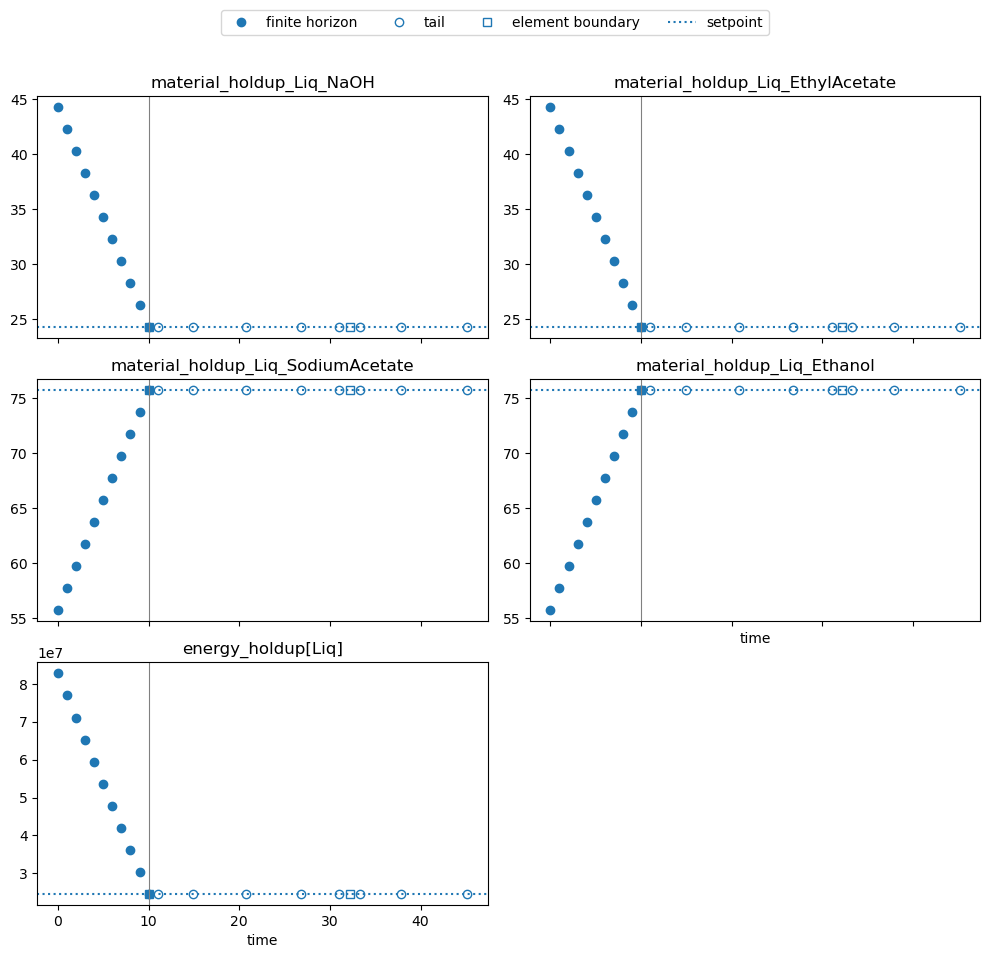

In [10]:
plot_states(m);
plt.show()

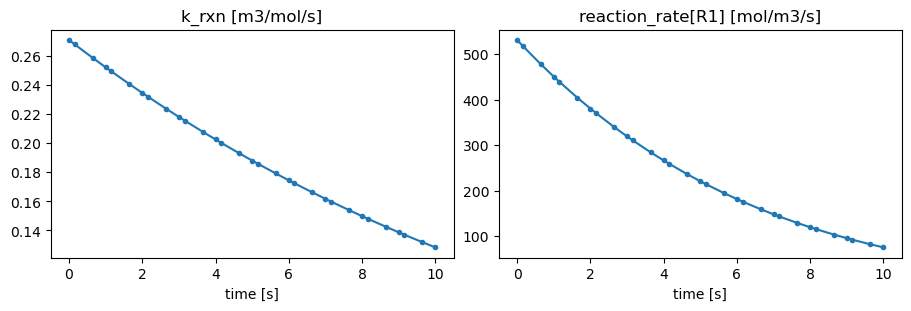

In [11]:
plot_rates(m)
plt.show()

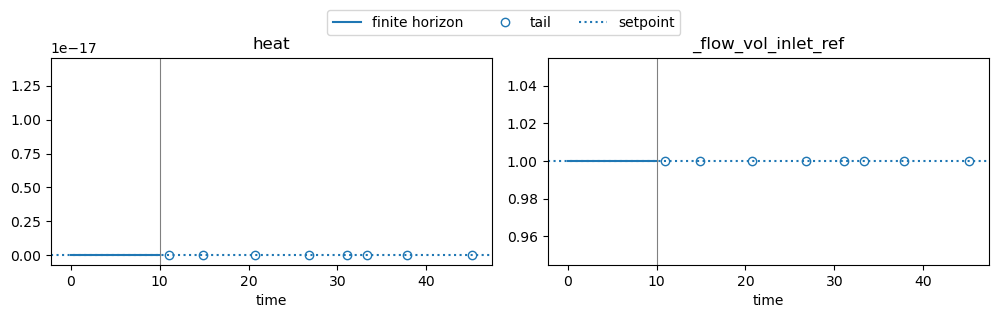

In [12]:
plot_controls(m);
plt.show()

## The first solve

The controller from the cold-started guess, through the scaled solve.
The log shows the iteration count from the linear start.

In [13]:
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
res = scaled_solve(m, tee=True)
print(res.solver.termination_condition)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:     4472
Number of nonzeros in inequality constraint Jacobian.:       20
Number of nonzeros in Lagrangian Hessian.............:      645

Total number of variables............................:     1414
                     variables with only lower bounds:      342
                variables with lower and upper bounds:       92
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1343
Total number of inequality constraints...............:        4
        inequality constraints with only lower bounds:        4
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  1.3163721e+04 4.74e+02 1.01e+02   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  1.2817837e+04 4.58e+02 9.00e+01   -1.0 1.21e+03   -4.0 2.2

   2  1.0006709e+04 2.25e+04 1.63e+02   -1.0 4.73e+02   -3.6 2.66e-01 1.00e+00f  1
   3  9.5621140e+03 1.46e+04 1.65e+02   -1.0 2.58e+02   -3.1 3.41e-01 3.96e-01h  1


   4  8.1335617e+03 1.35e+04 1.75e+03   -1.0 5.70e+02   -3.6 3.65e-01 6.41e-01f  1
   5  8.3083242e+03 3.49e+03 1.16e+05   -1.0 2.04e+02   -1.4 2.68e-02 1.00e+00h  1


   6  8.5602611e+03 4.05e+03 2.07e+04   -1.0 2.01e+02   -1.9 4.32e-02 1.00e+00h  1
   7  8.6664802e+03 1.02e+03 9.11e+03   -1.0 1.08e+02   -2.3 7.52e-01 1.00e+00h  1
   8  5.4238737e+03 9.85e+02 8.78e+03   -1.0 5.22e+04      - 1.33e-01 3.63e-02f  1


   9  5.2551840e+03 2.12e+02 6.21e+02   -1.0 1.20e+02   -2.8 2.24e-01 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  1.3740315e+03 1.67e+02 4.63e+02   -1.0 8.63e+04      - 5.50e-01 3.21e-01f  1
  11  2.3252369e+03 1.03e+02 2.24e+02   -1.0 1.77e+05      - 1.51e-01 1.00e+00h  1
  12  3.0641164e+03 2.74e+01 9.72e+01   -1.0 2.07e+05      - 9.90e-01 1.00e+00h  1


  13  3.5289274e+03 1.60e+00 1.13e+01   -1.0 2.04e+07      - 9.91e-01 1.00e+00h  1
  14  3.5490754e+03 1.14e-02 1.71e-01   -1.0 1.58e+09      - 1.00e+00 1.00e+00h  1
  15  3.5366046e+03 1.15e-01 1.92e-02   -2.5 1.11e+08      - 1.00e+00 1.00e+00f  1
  16  3.5379134e+03 1.50e-04 5.27e-05   -2.5 3.82e+09      - 1.00e+00 1.00e+00h  1


  17  3.5376452e+03 1.01e-04 1.77e-05   -3.8 1.31e+01      - 1.00e+00 1.00e+00h  1
  18  3.5376315e+03 3.23e-07 5.76e-08   -5.7 7.24e-01      - 1.00e+00 1.00e+00h  1
  19  3.5376313e+03 9.31e-09 8.50e-12   -8.6 9.02e-03      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 19

                                   (scaled)                 (unscaled)
Objective...............:   3.5376313202200117e+02    3.5376313202200117e+03
Dual infeasibility......:   8.5014113804238178e-12    8.5014113804238178e-11
Constraint violation....:   9.3132257461547852e-09    9.5367431640625000e-07
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5074010251796357e-09    2.5074010251796356e-08
Overall NLP error.......:   9.3132257461547852e-09    9.5367431640625000e-07


Number of objective function evaluations             = 20
Number of objective gradient evaluations             = 20
Number of equality constraint evaluations            = 20
Number of 

optimal


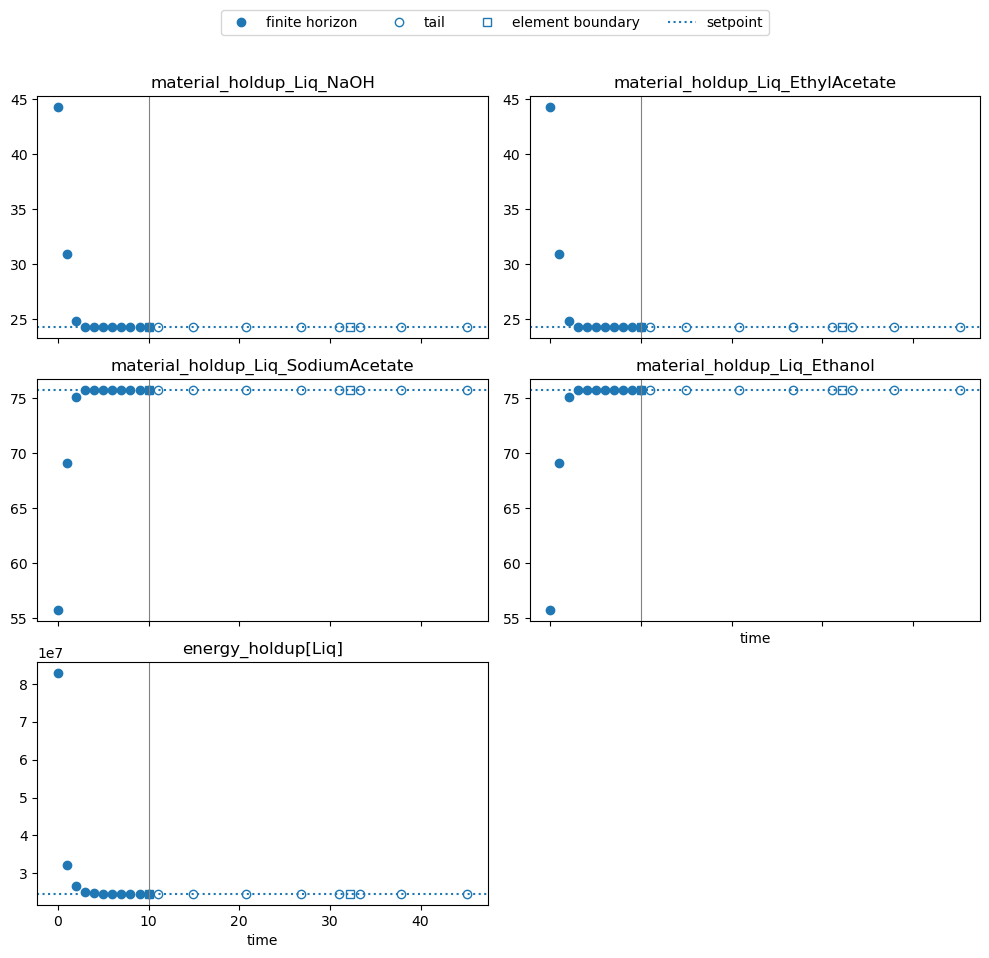

In [14]:
plot_states(m);
plt.show()

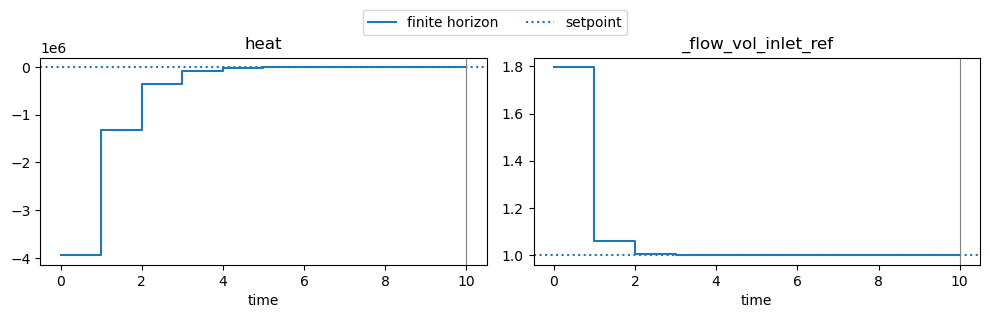

In [15]:
plot_controls(m);
plt.show()

## From scratch, with an exponential profile

The same model rebuilt and refilled, cold-started on the normalized
exponential decay instead of the line (time constant 3 s), and the same
solve again: compare the iteration count with the linear start above.

In [16]:
m2 = build()
for j, ssp in (("NaOH", m2.ss_naoh), ("EthylAcetate", m2.ss_ea),
               ("SodiumAcetate", m2.ss_sa), ("Ethanol", m2.ss_etoh)):
    ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
               ("SodiumAcetate", -1), ("Ethanol", -1)):
    m2.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
for k in m2.eng_ss:
    m2.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
pyo.TransformationFactory("drto.infinite_horizon").apply_to(m2)

tag_scaling(m2)
print(drto.cold_start_dynamic(m2, profile="exponential", time_constant=.3))

drto cold_start_dynamic (interpolate to the targets)
  states        : 5 on an exponential decay (time constant 0.3) across 31 grid points
  derivatives   : 155 at the profile's slope
  controls      : 2 at their targets
  segment       : 12 copies at the targets, slacks at zero
  point solves  : run (pyomo-pounce block solve, scaled clone)
  pyomo-pounce initialize (fill -> repair -> block-solve)
    decisions held: 342
    values filled : 0
    projection    : skipped
    pyomo-pounce block_initialize
      decisions fixed   : 0
      system square     : True
      blocks solved     : 1001 (1001 by Newton 1x1, 0 subsystem solves)
      vars initialized  : 1001
      left untouched    : 0 underdetermined, 0 overdetermined


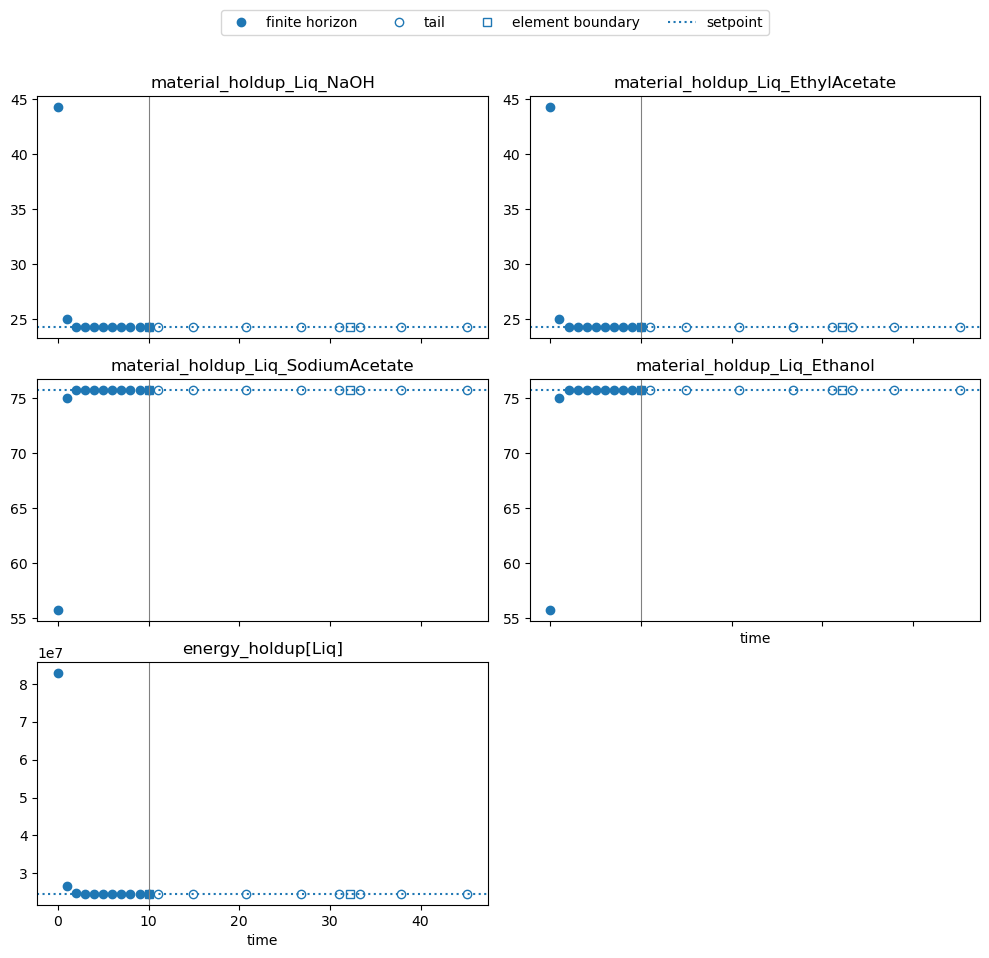

In [17]:
plot_states(m2)
plt.show()

In [18]:
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m2)
res = scaled_solve(m2, tee=True)
print(res.solver.termination_condition)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:     4472
Number of nonzeros in inequality constraint Jacobian.:       20
Number of nonzeros in Lagrangian Hessian.............:      645

Total number of variables............................:     1414
                     variables with only lower bounds:      342
                variables with lower and upper bounds:       92
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1343
Total number of inequality constraints...............:        4
        inequality constraints with only lower bounds:        4
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  3.4982381e+03 4.09e+02 1.01e+02   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  3.3995575e+03 3.96e+02 7.55e+01   -1.0 3.66e+02   -4.0 5.9

   2  3.4865434e+03 9.41e+01 1.87e+01   -1.0 3.51e+02   -4.5 7.55e-01 1.00e+00h  1
   3  3.5234401e+03 1.94e+01 5.12e-01   -1.0 8.01e+04      - 9.73e-01 1.00e+00h  1
   4  3.5492378e+03 1.24e-02 6.01e-03   -1.0 2.95e+06      - 9.90e-01 1.00e+00h  1


   5  3.5492245e+03 1.50e-08 2.98e-05   -1.0 2.81e+08      - 9.94e-01 1.00e+00f  1
   6  3.5388260e+03 1.03e-01 1.30e-02   -1.7 9.47e+08      - 1.00e+00 1.00e+00f  1
   7  3.5378552e+03 7.12e-03 9.74e-04   -2.5 6.09e+08      - 1.00e+00 1.00e+00h  1
   8  3.5376451e+03 1.54e-04 2.06e-05   -3.8 1.97e+08      - 1.00e+00 1.00e+00h  1
   9  3.5376315e+03 4.43e-07 5.80e-08   -5.7 4.29e+07      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  3.5376313e+03 3.26e-09 8.50e-12   -8.6 4.70e+06      - 1.00e+00 1.00e+00h  1




Number of Iterations....: 10

                                   (scaled)                 (unscaled)
Objective...............:   3.5376313202200123e+02    3.5376313202200122e+03
Dual infeasibility......:   8.5021187139211474e-12    8.5021187139211474e-11
Constraint violation....:   3.2596290111541748e-09    2.3841857910156250e-07
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5075707335982233e-09    2.5075707335982231e-08
Overall NLP error.......:   3.2596290111541748e-09    2.3841857910156250e-07


Number of objective function evaluations             = 11
Number of objective gradient evaluations             = 11
Number of equality constraint evaluations            = 11
Number of inequality constraint evaluations          = 11
Number of equality constraint Jacobian evaluations   = 11
Number of inequality constraint Jacobian evaluations = 11
Number of Lagrangian Hessian evaluations             = 11
Total seconds in POUNCE    

optimal


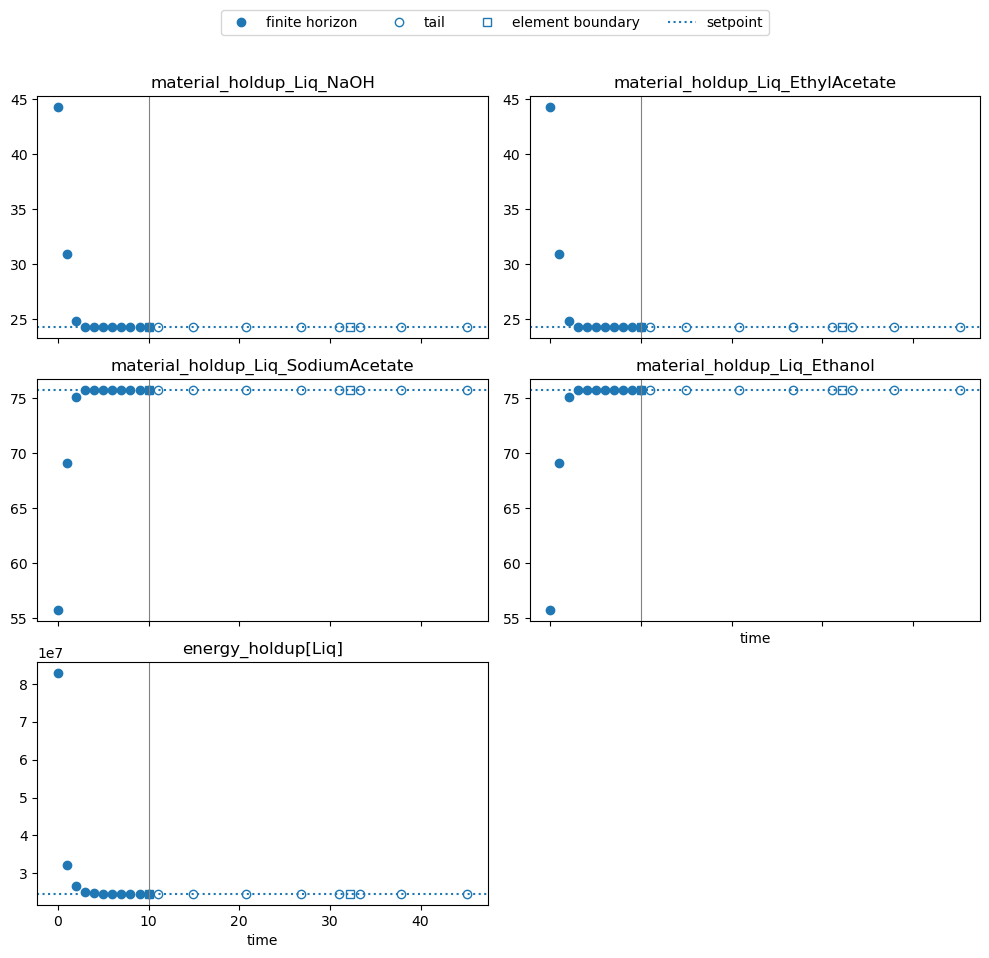

In [19]:
plot_states(m2);
plt.show()